✅ Dataset loaded successfully!

--- Columns ---
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

--- First 3 Rows ---
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   

       AH  
0  0,7578  
1  0,7255  
2  0,7502  

✅ Date and Time merged successfully.

✅ Missing values handled successfully.

✅ Po

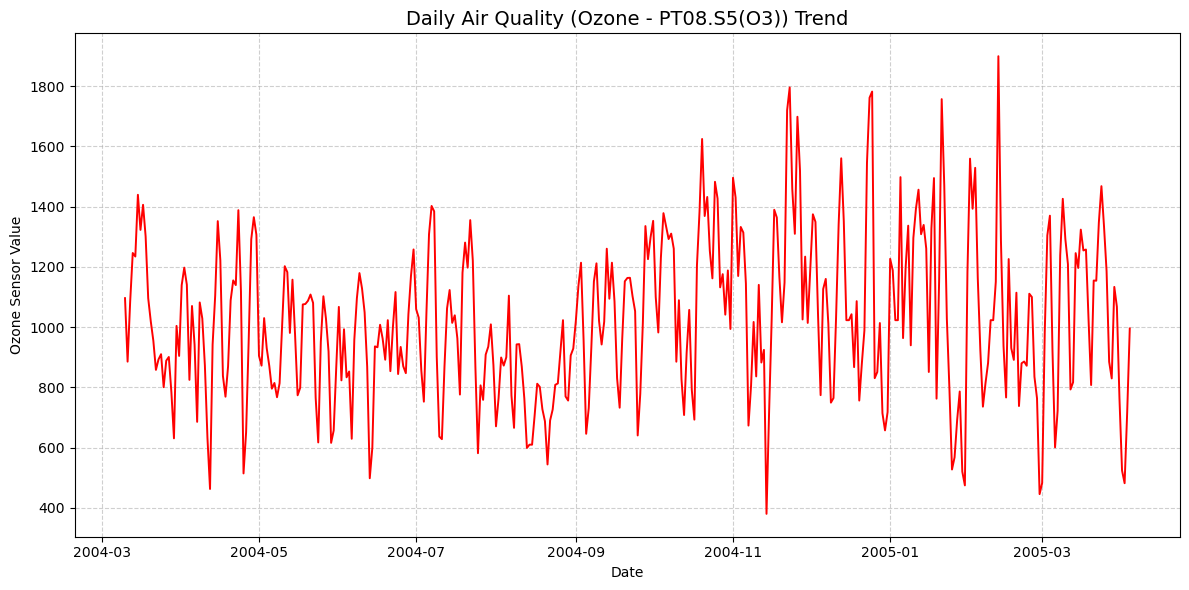

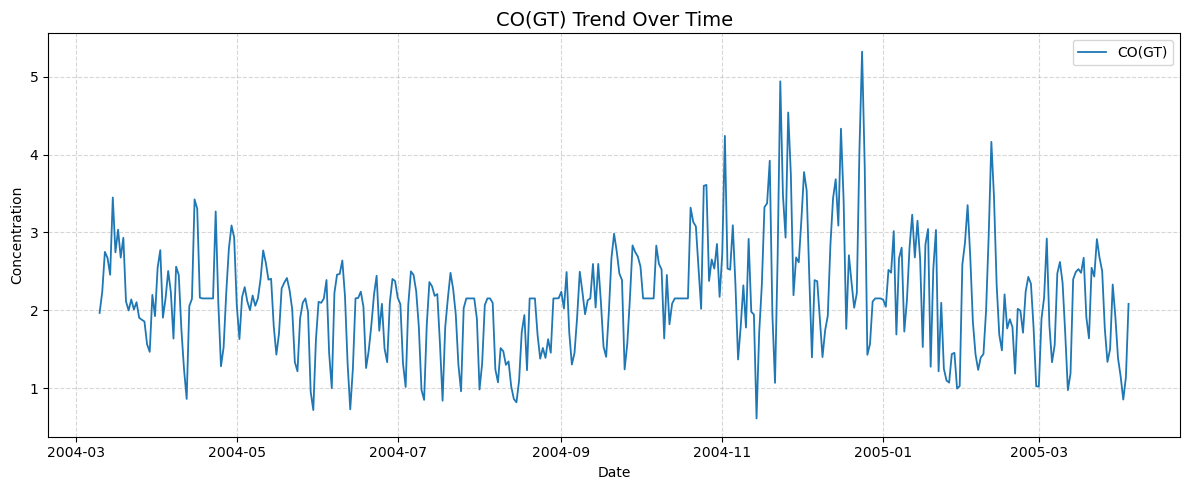

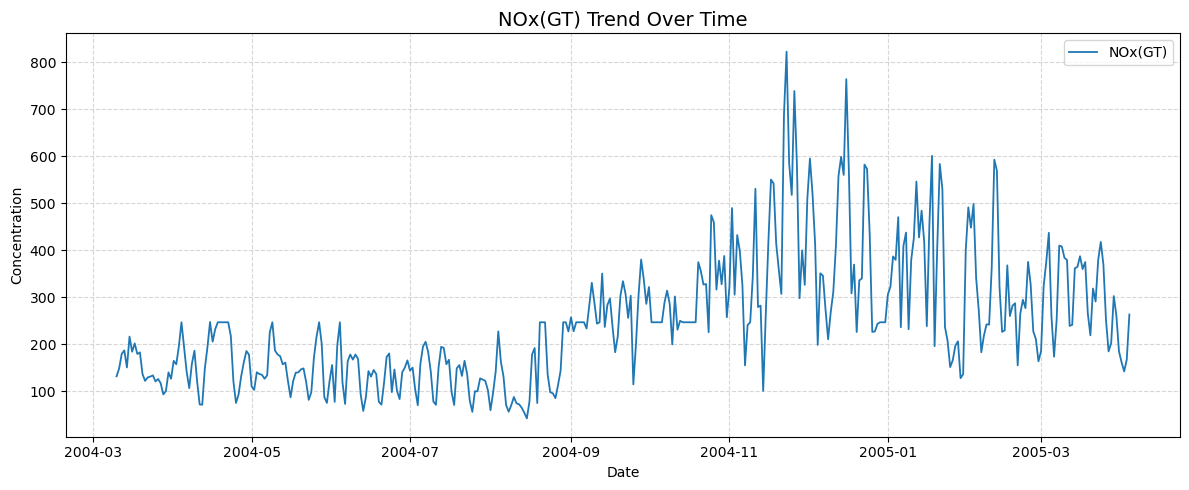

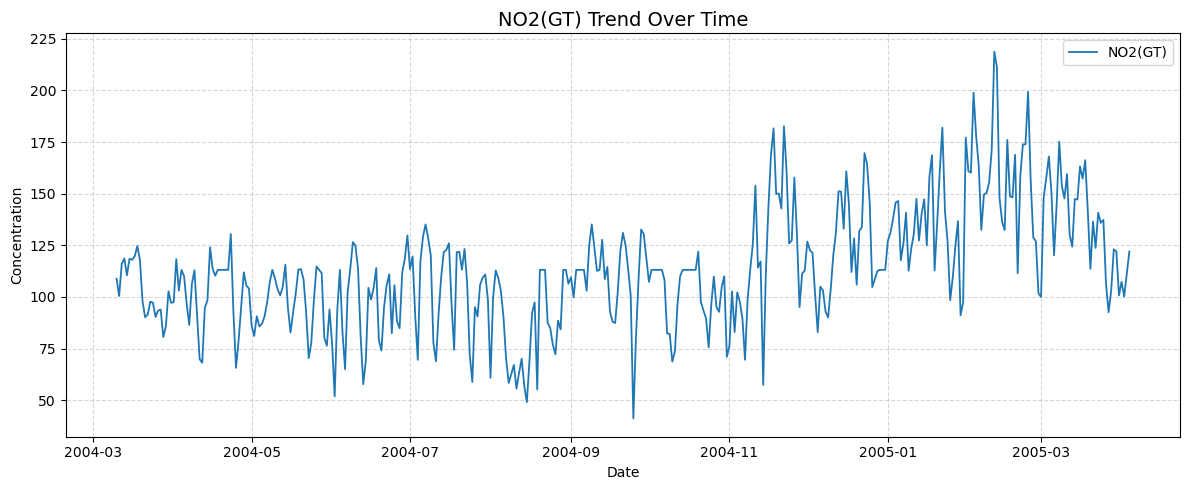

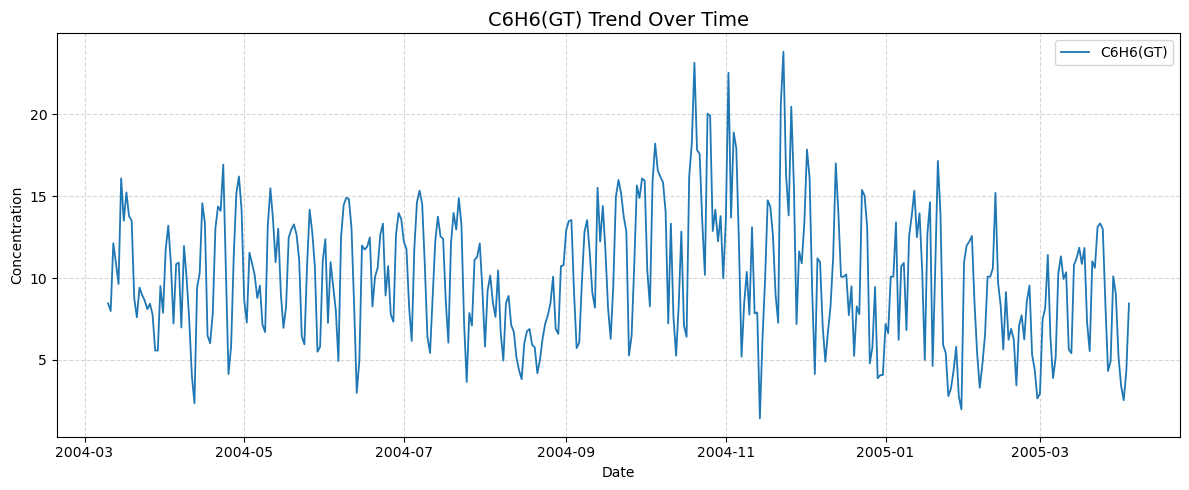

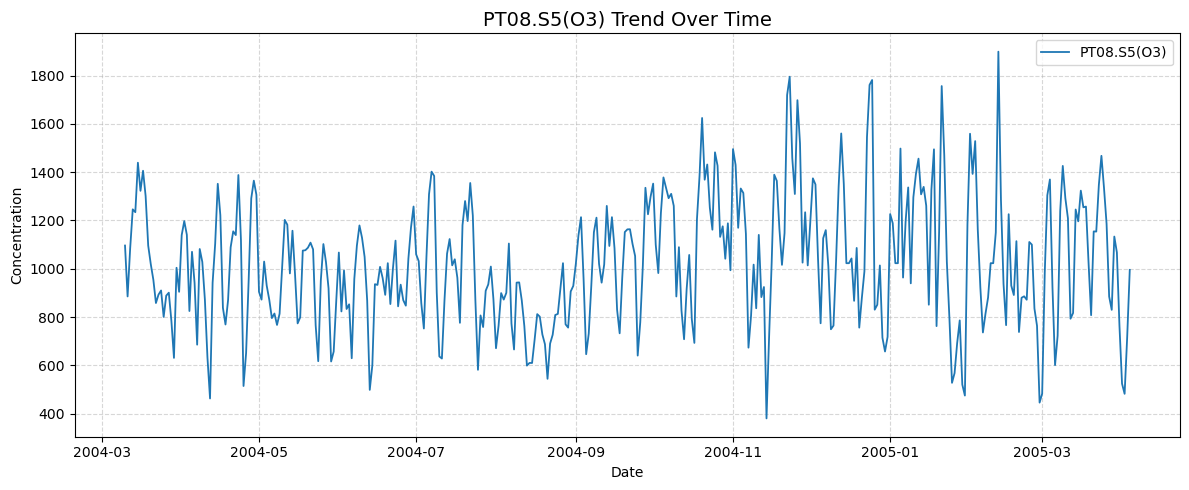

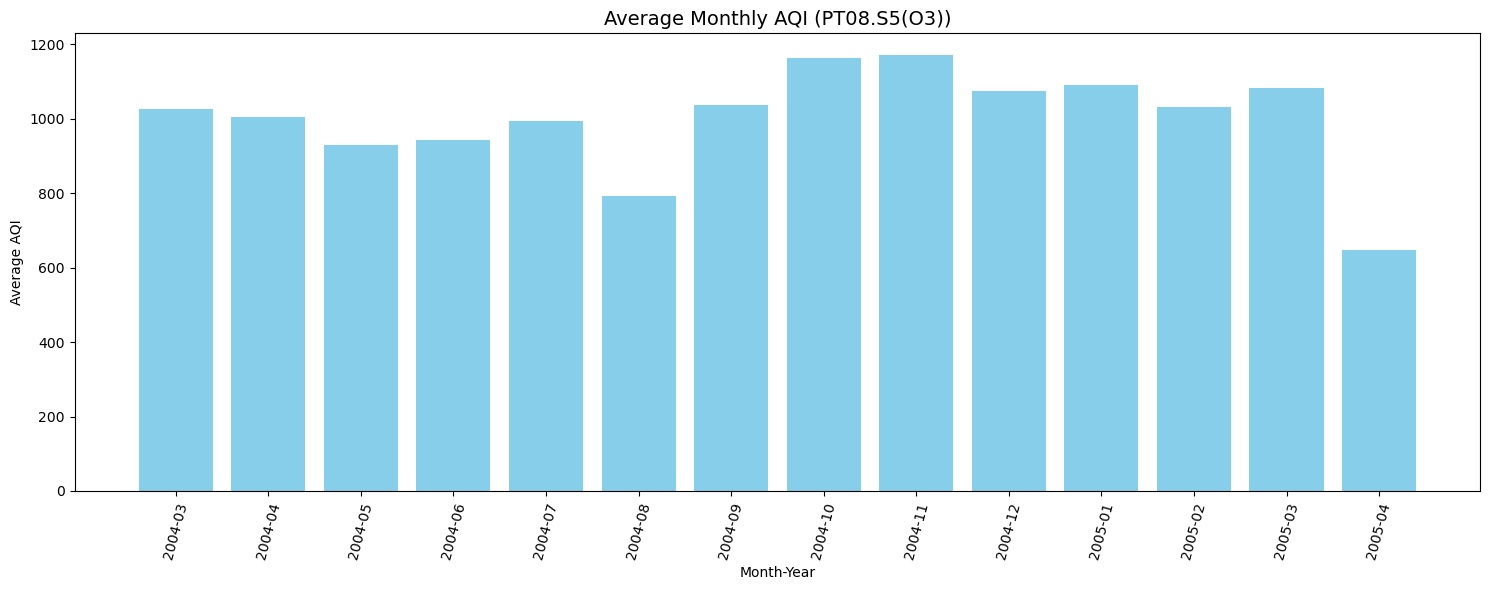

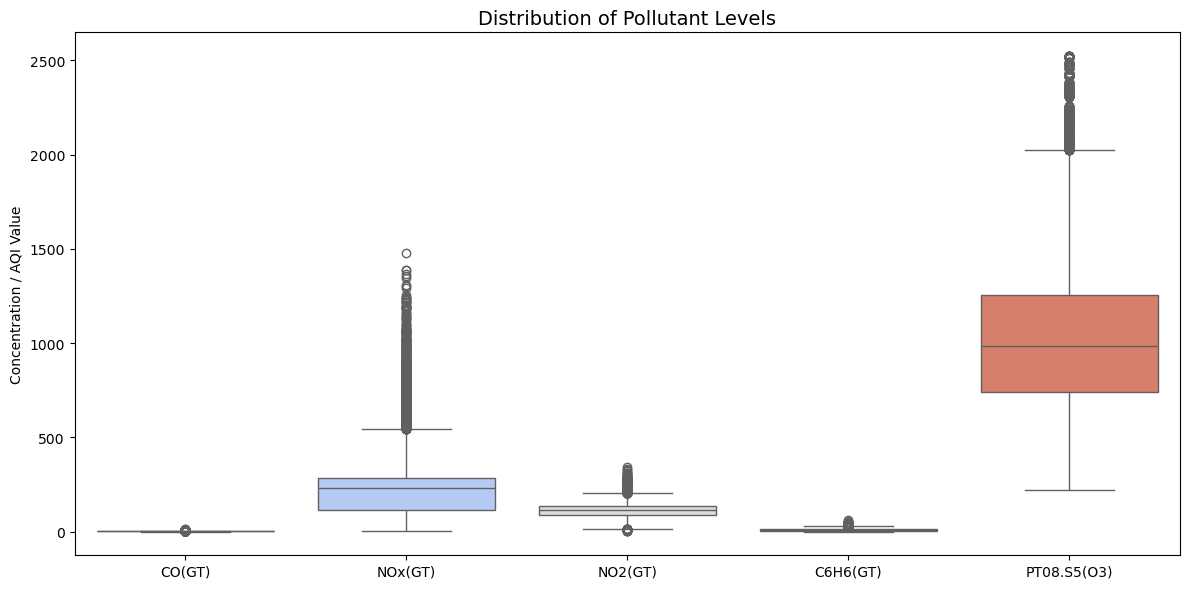

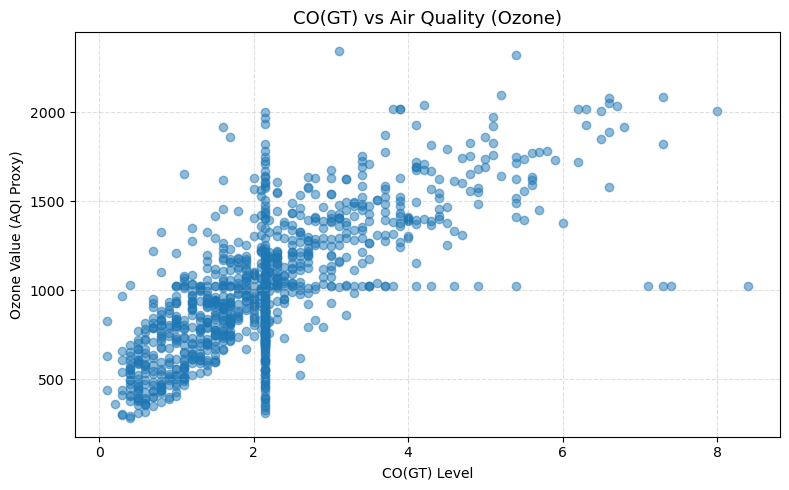

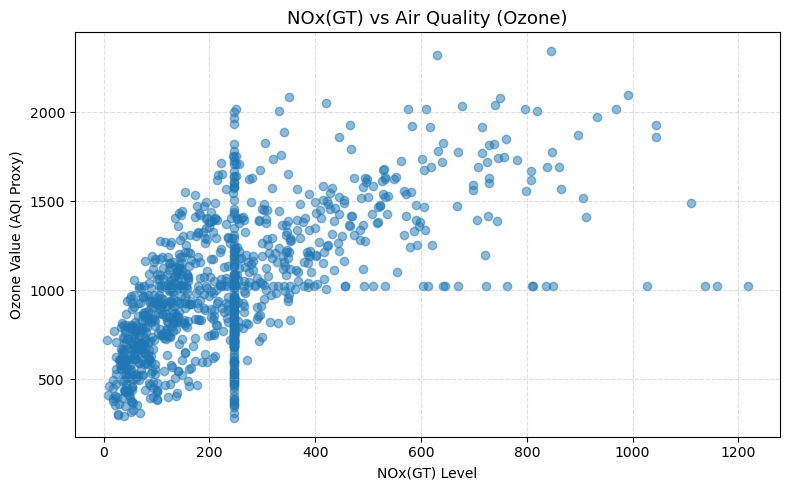

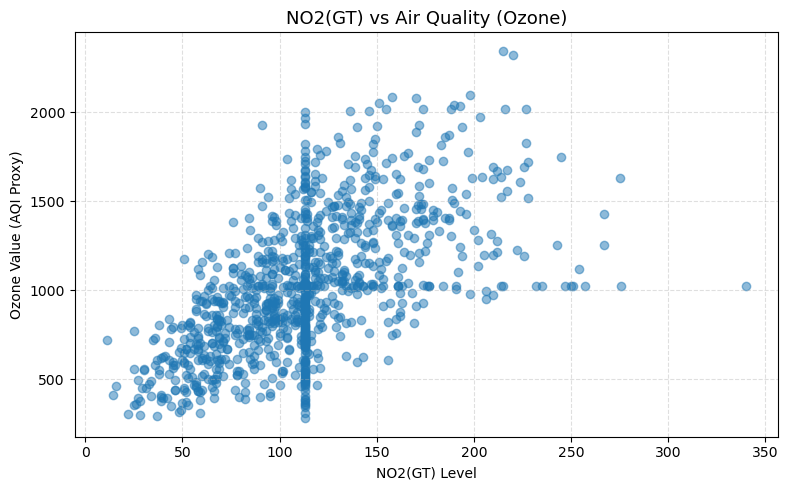

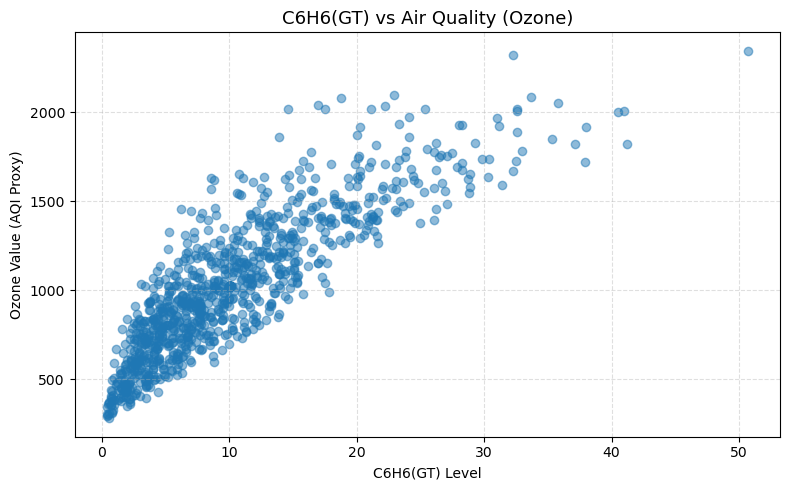

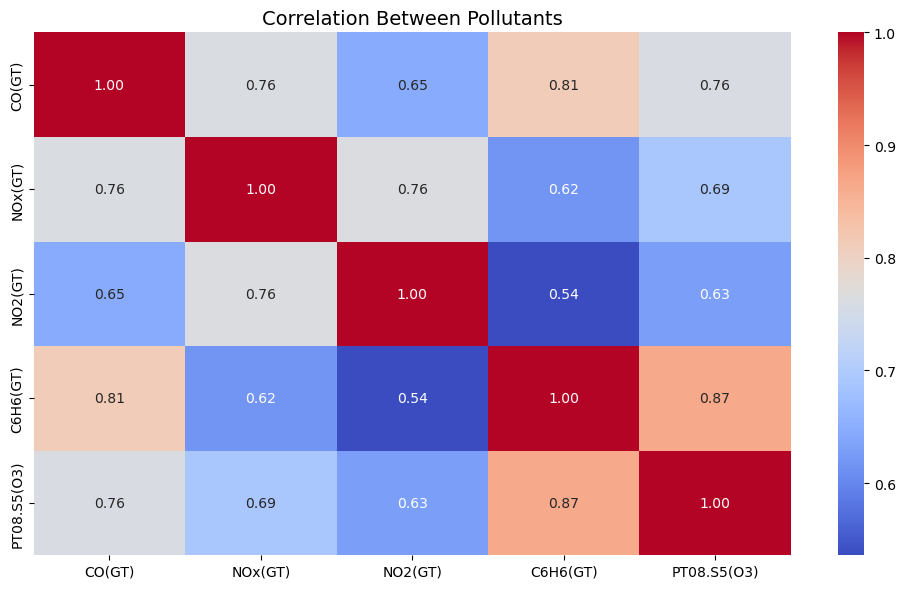


✅ All steps completed successfully.


In [1]:
#%% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

#%% Step 2: Load Dataset (semicolon-separated)
df = pd.read_csv("City_Air_Quality.csv", sep=';', low_memory=False)
print("✅ Dataset loaded successfully!")

# Drop fully empty columns (common at file end)
df = df.dropna(axis=1, how='all')

print("\n--- Columns ---")
print(df.columns.tolist())
print("\n--- First 3 Rows ---")
print(df.head(3))

#%% Step 3: Fix Date and Time Columns
if 'Date' in df.columns and 'Time' in df.columns:
    # Replace '.' with ':' in Time (e.g., 18.00.00 → 18:00:00)
    df['Time'] = df['Time'].astype(str).str.replace('.', ':', regex=False)
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce', dayfirst=True)
elif 'Date' in df.columns:
    df['DateTime'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
else:
    raise ValueError("❌ No valid 'Date' or 'Time' columns found. Check your CSV header.")

# Drop rows without valid datetime
df = df.dropna(subset=['DateTime'])

# Set datetime index
df = df.set_index('DateTime')

# Drop old Date/Time columns
df = df.drop(columns=['Date', 'Time'], errors='ignore')

print("\n✅ Date and Time merged successfully.")

#%% Step 4: Clean numeric columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace -200 with NaN (invalid sensor readings)
df = df.replace(-200, np.nan)

#%% Step 5: Handle Missing Values
imputer = SimpleImputer(strategy='mean')
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("\n✅ Missing values handled successfully.")

#%% Step 6: Identify Pollutants
pollutant_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)', 'PT08.S5(O3)']
pollutant_cols = [p for p in pollutant_cols if p in df.columns]
print(f"\n✅ Pollutants found: {pollutant_cols}")

# AQI proxy (Ozone)
aqi_proxy_col = 'PT08.S5(O3)' if 'PT08.S5(O3)' in df.columns else pollutant_cols[0]

#%% Step 7: Resample Data (Daily & Monthly)
df_daily = df.resample('D').mean()
df_monthly = df.resample('M').mean()
print("\n✅ Data resampled to daily and monthly averages.")

#%% Step 8: Plot AQI (Ozone) Daily Trend
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily[aqi_proxy_col], color='red', linewidth=1.4)
#for pollutant in pollutant_cols:
#    plt.plot(df_daily.index, df_daily[pollutant], label=pollutant, linewidth=1)
plt.title(f"Daily Air Quality (Ozone - {aqi_proxy_col}) Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Ozone Sensor Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#%% Step 9: Separate Pollutant Graphs
for pollutant in pollutant_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(df_daily.index, df_daily[pollutant], label=pollutant, linewidth=1.3)
    plt.title(f"{pollutant} Trend Over Time", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Concentration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

#%% Step 10: Monthly AQI Bar Plot
plt.figure(figsize=(15, 6))
plt.bar(df_monthly.index.strftime('%Y-%m'), df_monthly[aqi_proxy_col], color='skyblue')
plt.title(f"Average Monthly AQI ({aqi_proxy_col})", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Average AQI")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#%% Step 11: Box Plot — Pollutant Distributions
if len(pollutant_cols) > 1:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[pollutant_cols + [aqi_proxy_col]], palette="coolwarm")
    plt.title("Distribution of Pollutant Levels", fontsize=14)
    plt.ylabel("Concentration / AQI Value")
    plt.tight_layout()
    plt.show()

#%% Step 12: Scatter Plots — Pollutants vs AQI
df_sample = df.sample(min(1000, len(df)))
for pollutant in pollutant_cols:
    if pollutant != aqi_proxy_col:
        plt.figure(figsize=(8, 5))
        plt.scatter(df_sample[pollutant], df_sample[aqi_proxy_col], alpha=0.5)
        plt.title(f"{pollutant} vs Air Quality (Ozone)", fontsize=13)
        plt.xlabel(f"{pollutant} Level")
        plt.ylabel("Ozone Value (AQI Proxy)")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

#%% Step 13: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[pollutant_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Pollutants", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ All steps completed successfully.")
